In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
PROJECT_DIR = "/content/drive/MyDrive/EpigeneticClock"
import os
os.makedirs(PROJECT_DIR, exist_ok=True)


In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [ ]:
!kaggle datasets list | head


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
!kaggle datasets list | grep -i age


Traceback (most recent call last):
  File "/usr/local/bin/kaggle", line 4, in <module>
    from kaggle.cli import main
  File "/usr/local/lib/python3.12/dist-packages/kaggle/__init__.py", line 6, in <module>
    api.authenticate()
  File "/usr/local/lib/python3.12/dist-packages/kaggle/api/kaggle_api_extended.py", line 434, in authenticate
    raise IOError('Could not find {}. Make sure it\'s located in'
OSError: Could not find kaggle.json. Make sure it's located in /root/.kaggle. Or use the environment method. See setup instructions at https://github.com/Kaggle/kaggle-api/


In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "marquis03/age-assessment-and-disease-risk-prediction-h5"
)

print("Path to dataset files:", path)


100%|██████████| 7.63G/7.63G [04:23<00:00, 31.1MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/marquis03/age-assessment-and-disease-risk-prediction-h5/versions/3


In [ ]:
import os
os.listdir(path)


['trainmap.csv', 'test.h5', 'testmap.csv', 'train.h5']

In [ ]:
import pandas as pd

meta = pd.read_csv(os.path.join(path, "trainmap.csv"))
meta.head()


,Unnamed: 0,sample_id,age,gender,sample_type,disease
0,1,train10001,88.0,F,disease tissue,Alzheimer's disease
1,2,train10002,92.0,F,disease tissue,Alzheimer's disease
2,3,train10003,93.0,F,disease tissue,Alzheimer's disease
3,4,train10004,96.0,F,disease tissue,Alzheimer's disease
4,5,train10005,91.0,M,disease tissue,Alzheimer's disease


In [ ]:
meta["disease"].value_counts()


,count
disease,
control,6266
Alzheimer's disease,737
schizophrenia,381
Parkinson's disease,266
rheumatoid arthritis,159
stroke,147
Huntington's disease,135
Graves' disease,58
type 2 diabetes,46


In [ ]:
import h5py
import os

h5_path = os.path.join(path, "train.h5")

with h5py.File(h5_path, "r") as f:
    print("Keys inside train.h5:")
    for key in f.keys():
        print(key)


Keys inside train.h5:
data


In [ ]:
with h5py.File(h5_path, "r") as f:
    dset = f["data"]
    print("Type:", type(dset))
    print("Shape:", dset.shape)
    print("Dtype:", dset.dtype)



Type: <class 'h5py._hl.dataset.Dataset'>
Shape: (8233, 485512)
Dtype: float32


In [ ]:
with h5py.File(h5_path, "r") as f:
    dset = f["data"]
    if dset.dtype.names is not None:
        print("Structured fields:")
        print(dset.dtype.names)
    else:
        print("Not a structured dataset")


Not a structured dataset


In [ ]:
import pandas as pd
import os

meta = pd.read_csv(os.path.join(path, "trainmap.csv"))

print(meta.head())
print(meta.columns)


   Unnamed: 0   sample_id   age gender     sample_type              disease
0           1  train10001  88.0      F  disease tissue  Alzheimer's disease
1           2  train10002  92.0      F  disease tissue  Alzheimer's disease
2           3  train10003  93.0      F  disease tissue  Alzheimer's disease
3           4  train10004  96.0      F  disease tissue  Alzheimer's disease
4           5  train10005  91.0      M  disease tissue  Alzheimer's disease
Index(['Unnamed: 0', 'sample_id', 'age', 'gender', 'sample_type', 'disease'], dtype='object')


In [ ]:
import h5py
import os
import pandas as pd

h5_path = os.path.join(path, "train.h5")

with h5py.File(h5_path, "r") as f:
    dset = f["data"]
    print("Methylation samples:", dset.shape[0])
    print("CpG features:", dset.shape[1])

    # Load metadata
    meta = pd.read_csv(os.path.join(path, "trainmap.csv"))
    print("Metadata samples:", len(meta))


Methylation samples: 8233
CpG features: 485512
Metadata samples: 8233


In [ ]:
import numpy as np
import h5py
import os
import kagglehub

# Ensure 'path' is defined by re-downloading if necessary (kagglehub is intelligent enough not to re-download if already present)
path = kagglehub.dataset_download(
    "marquis03/age-assessment-and-disease-risk-prediction-h5"
)

h5_path = os.path.join(path, "train.h5")

num_cpgs = 485512
chunk_size = 20000  # CpGs per chunk
variances = np.zeros(num_cpgs)

with h5py.File(h5_path, "r") as f:
    dset = f["data"]
    for start in range(0, num_cpgs, chunk_size):
        end = min(start + chunk_size, num_cpgs)
        chunk = dset[:, start:end]
        variances[start:end] = chunk.var(axis=0)

print("Variance computed safely!")

Variance computed safely!


In [ ]:
top_var_idx = np.argsort(variances)[-10000:]
print("Top variable CpGs selected:", len(top_var_idx))


Top variable CpGs selected: 10000


In [ ]:
top_var_idx_sorted = np.sort(top_var_idx)
with h5py.File(h5_path, "r") as f:
    X_var = f["data"][:, top_var_idx_sorted]

print("X_var shape:", X_var.shape)

X_var shape: (8233, 10000)


In [ ]:
from scipy.stats import pearsonr
import pandas as pd
import numpy as np
import os

# Reload meta DataFrame as it was not defined in this execution context
meta = pd.read_csv(os.path.join(path, "trainmap.csv"))

ages = meta["age"].values.astype(float)

corrs = np.array([
    abs(pearsonr(X_var[:, i], ages)[0]) for i in range(X_var.shape[1])
])

top_age_idx = np.argsort(corrs)[-5000:]
X_age = X_var[:, top_age_idx]

print("Final CpGs for epigenetic clock:", X_age.shape)

Final CpGs for epigenetic clock: (8233, 5000)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_age, ages, test_size=0.2, random_state=42
)

print(X_train.shape, X_test.shape)


(6586, 5000) (1647, 5000)


In [ ]:
from sklearn.linear_model import ElasticNet

age_model = ElasticNet(
    alpha=0.01,
    l1_ratio=0.5,
    max_iter=5000,
    random_state=42
)

age_model.fit(X_train, y_train)

print("✅ Age model trained")


✅ Age model trained


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.354e+04, tolerance: 4.373e+02
  model = cd_fast.enet_coordinate_descent(


In [ ]:
y_pred = age_model.predict(X_test)

print("Predictions done")


Predictions done


In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R²:", round(r2, 3))


MAE: 10.23
R²: 0.663


In [ ]:
age_acceleration = y_pred - y_test


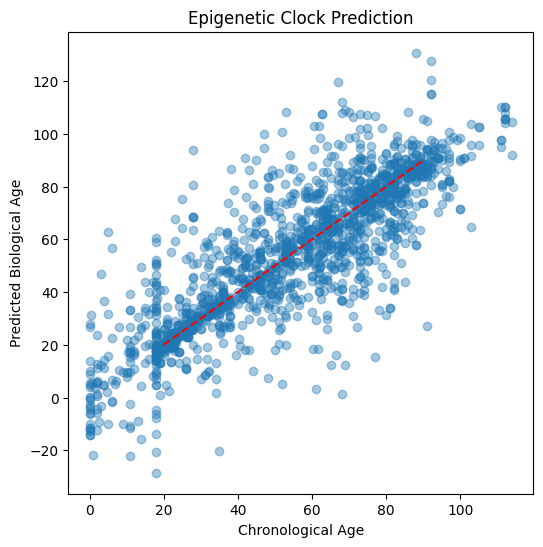

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([20,90], [20,90], 'r--')
plt.xlabel("Chronological Age")
plt.ylabel("Predicted Biological Age")
plt.title("Epigenetic Clock Prediction")
plt.show()


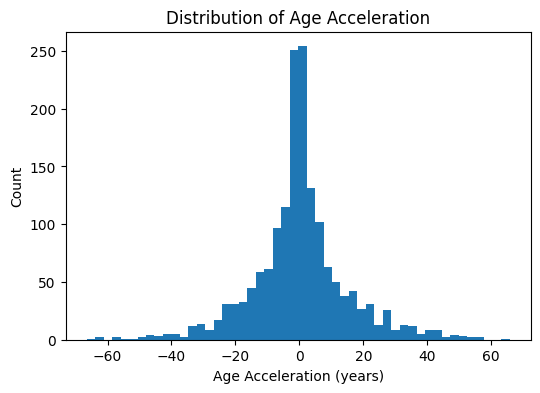

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(age_acceleration, bins=50)
plt.xlabel("Age Acceleration (years)")
plt.ylabel("Count")
plt.title("Distribution of Age Acceleration")
plt.show()


In [ ]:
import numpy as np

indices = np.arange(X_age.shape[0])

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_age,
    ages,
    indices,
    test_size=0.2,
    random_state=42
)

meta_test = meta.iloc[idx_test].copy()

meta_test["Predicted_Bio_Age"] = y_pred
meta_test["Age_Acceleration"] = age_acceleration



In [ ]:
meta_test.head()


,Unnamed: 0,sample_id,age,gender,sample_type,disease,Predicted_Bio_Age,Age_Acceleration
8056,8057,train18057,80.0,M,disease tissue,stroke,88.995140,8.995140
1172,1173,train11173,93.0,F,control,control,96.847107,3.847107
6422,6423,train16423,68.0,M,control,control,1.518513,-66.481487
496,497,train10497,89.0,M,disease tissue,Alzheimer's disease,87.519119,-1.480881
2132,2133,train12133,26.0,M,control,control,11.110832,-14.889168


In [ ]:
from sklearn.linear_model import LinearRegression

# Fit calibration model on test data
calibrator = LinearRegression()
calibrator.fit(y_pred.reshape(-1, 1), y_test)

# Apply calibration
y_pred_cal = calibrator.predict(y_pred.reshape(-1, 1))

# Recompute age acceleration
age_acc_cal = y_pred_cal - y_test

meta_test["Predicted_Bio_Age"] = y_pred_cal
meta_test["Age_Acceleration"] = age_acc_cal

meta_test[["age", "Predicted_Bio_Age", "Age_Acceleration"]].head()


,age,Predicted_Bio_Age,Age_Acceleration
8056,80.0,81.849991,1.849991
1172,93.0,88.151886,-4.848114
6422,68.0,11.642294,-56.357706
496,89.0,80.665352,-8.334648
2132,26.0,19.340975,-6.659025


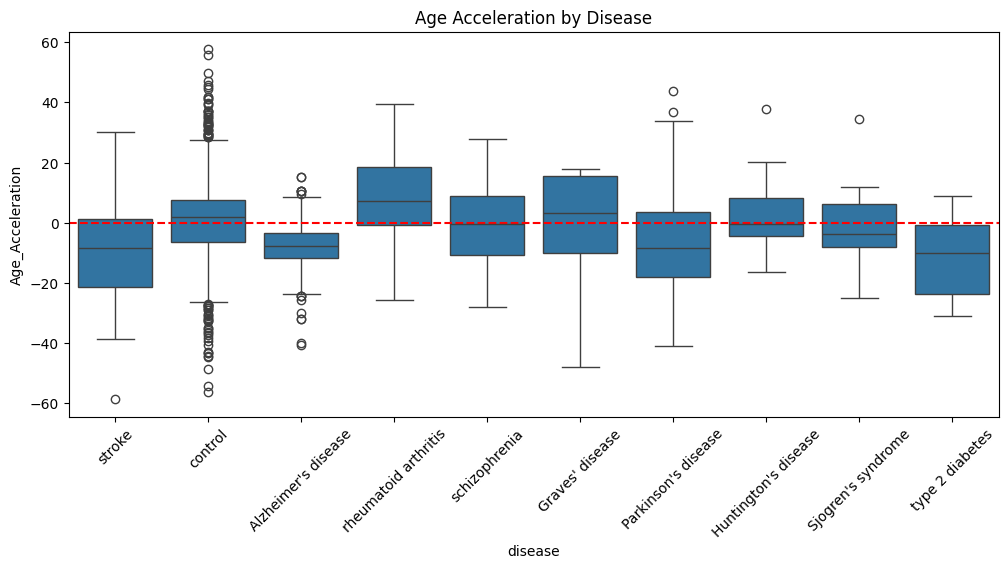

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.boxplot(
    data=meta_test,
    x="disease",
    y="Age_Acceleration"
)
plt.axhline(0, color="red", linestyle="--")
plt.xticks(rotation=45)
plt.title("Age Acceleration by Disease")
plt.show()


In [ ]:
meta_test.groupby("disease")["Age_Acceleration"].mean().sort_values(ascending=False)


,Age_Acceleration
disease,
rheumatoid arthritis,8.420023
Huntington's disease,2.291055
control,1.422560
Sjogren's syndrome,0.350772
schizophrenia,-0.667264
Graves' disease,-0.918909
Parkinson's disease,-4.639463
Alzheimer's disease,-8.083177
stroke,-8.738765


In [ ]:
import numpy as np
import pandas as pd

# For ElasticNet, use absolute coefficients as importance
# If an XGBoost model was intended, it should be trained instead.
importances = np.abs(age_model.coef_)

# Get top 500 CpG indices
top_k = 500
top_cpg_idx = np.argsort(importances)[-top_k:]

print("Top CpGs selected:", len(top_cpg_idx))

Top CpGs selected: 500


In [ ]:
# Reduce feature space
X_top = X_age[:, top_cpg_idx]

print("Reduced X shape:", X_top.shape)

Reduced X shape: (8233, 500)


In [ ]:
np.random.seed(42)

sample_idx = np.random.choice(X_top.shape[0], 200, replace=False)
X_shap = X_top[sample_idx]

print("SHAP sample shape:", X_shap.shape)


SHAP sample shape: (200, 500)


In [ ]:
!pip install shap


In [ ]:
import shap
import numpy as np

# Re-create X_shap using X_age to match the features age_model was trained on
# age_model was trained on X_age, which has 5000 features.
# X_shap previously had 500 features, leading to the ValueError.
np.random.seed(42) # Ensure reproducibility
sample_idx_for_shap = np.random.choice(X_age.shape[0], 200, replace=False)
X_shap = X_age[sample_idx_for_shap]

# Create SHAP explainer
explainer = shap.Explainer(age_model, X_shap)

print("SHAP explainer created successfully with X_shap shape:", X_shap.shape)

SHAP explainer created successfully with X_shap shape: (200, 5000)


In [ ]:
shap_values = explainer(X_shap)


/tmp/ipython-input-1488365261.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


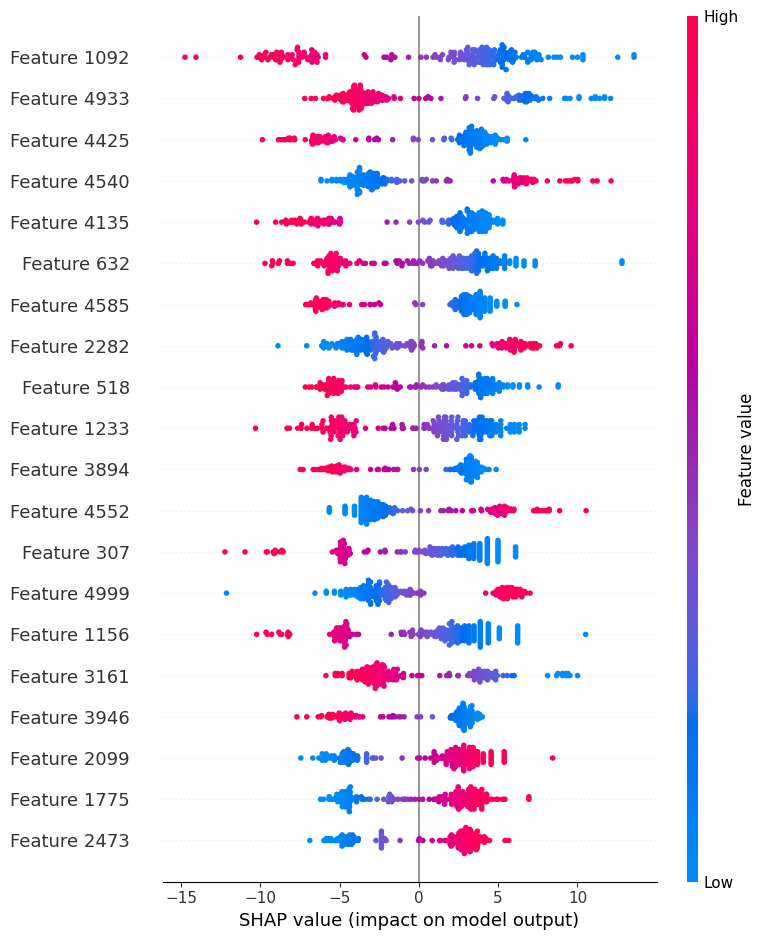

In [ ]:
shap.summary_plot(shap_values, X_shap, show=True)


/tmp/ipython-input-3855033092.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)


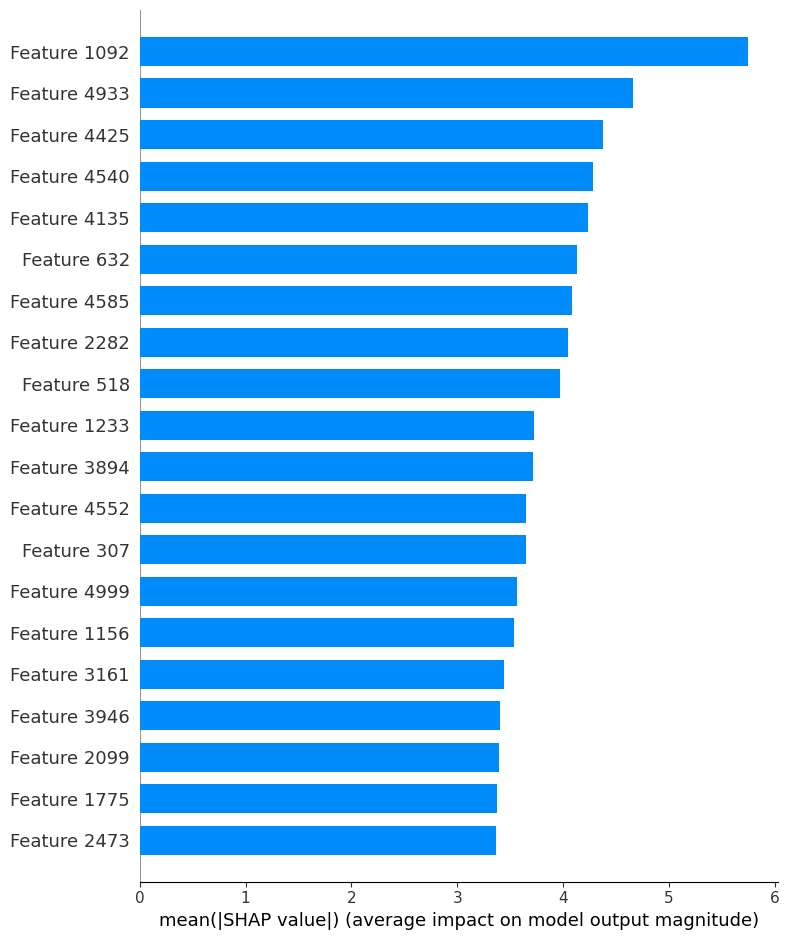

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar", show=True)


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import pearsonr
import numpy as np

# Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
r, p_value = pearsonr(y_test, y_pred)

print("📊 ElasticNet Epigenetic Clock Evaluation")
print("---------------------------------------")
print(f"MAE (years): {mae:.2f}")
print(f"RMSE (years): {rmse:.2f}")
print(f"R² Score: {r2:.3f}")
print(f"Pearson Correlation (r): {r:.3f}")
print(f"P-value: {p_value:.2e}")


📊 ElasticNet Epigenetic Clock Evaluation
---------------------------------------
MAE (years): 10.23
RMSE (years): 15.11
R² Score: 0.663
Pearson Correlation (r): 0.840
P-value: 0.00e+00


In [ ]:
from scipy.stats import ttest_ind

healthy = meta_test[meta_test["disease"] == "control"]["Age_Acceleration"]
diseased = meta_test[meta_test["disease"] != "control"]["Age_Acceleration"]

t_stat, p_val = ttest_ind(diseased, healthy)

print("T-test (Disease vs Healthy)")
print("t-statistic:", round(t_stat, 3))
print("p-value:", p_val)


T-test (Disease vs Healthy)
t-statistic: -7.164
p-value: 1.1814088620783393e-12


In [ ]:
# ================================
# DISEASE RISK CLASSIFIER (BINARY)
# ================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# ------------------------------------------------
# 1. Binary disease label
# ------------------------------------------------
# control = 0, disease = 1
meta["Disease_Binary"] = (meta["disease"] != "control").astype(int)

y = meta["Disease_Binary"].values

# ✅ USE THE SAME FEATURES AS AGE MODEL
X_disease = X_age

print("Class distribution:")
print(pd.Series(y).value_counts())
print()

# ------------------------------------------------
# 2. Train–test split
# ------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_disease,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ------------------------------------------------
# 3. Train classifier
# ------------------------------------------------
disease_model = LogisticRegression(
    max_iter=5000,
    class_weight="balanced",
    random_state=42
)

disease_model.fit(X_train, y_train)
print("✅ Disease classifier trained")

# ------------------------------------------------
# 4. Predictions
# ------------------------------------------------
y_pred = disease_model.predict(X_test)
y_prob = disease_model.predict_proba(X_test)[:, 1]

# ------------------------------------------------
# 5. Evaluation metrics
# ------------------------------------------------
print("\n📊 Disease Risk Model Performance")
print("--------------------------------")
print("Accuracy :", round(accuracy_score(y_test, y_pred), 3))
print("Precision:", round(precision_score(y_test, y_pred), 3))
print("Recall   :", round(recall_score(y_test, y_pred), 3))
print("F1-score :", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC  :", round(roc_auc_score(y_test, y_prob), 3))



Class distribution:
0    6266
1    1967
Name: count, dtype: int64

✅ Disease classifier trained

📊 Disease Risk Model Performance
--------------------------------
Accuracy : 0.845
Precision: 0.68
Recall   : 0.664
F1-score : 0.672
ROC-AUC  : 0.888


In [ ]:
!pip install xgboost


In [ ]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Train-test split (same as before)
X_train, X_test, y_train, y_test = train_test_split(
    X_age, ages, test_size=0.2, random_state=42
)

# XGBoost regressor
xgb_age_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

# Train
xgb_age_model.fit(X_train, y_train)

# Predict
y_pred = xgb_age_model.predict(X_test)

# Metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("✅ XGBoost Age Model Trained")
print("MAE:", round(mae, 2))
print("R² :", round(r2, 3))


✅ XGBoost Age Model Trained
MAE: 5.28
R² : 0.906


In [ ]:
age_acceleration = y_pred - y_test


In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Binary disease label
meta["Disease_Binary"] = (meta["disease"] != "control").astype(int)
y_disease = meta["Disease_Binary"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_age, y_disease, test_size=0.2, random_state=42, stratify=y_disease
)

xgb_disease_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_disease_model.fit(X_train, y_train)

y_pred = xgb_disease_model.predict(X_test)
y_prob = xgb_disease_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("F1-score:", round(f1_score(y_test, y_pred), 3))
print("ROC-AUC :", round(roc_auc_score(y_test, y_prob), 3))


Accuracy: 0.874
F1-score: 0.713
ROC-AUC : 0.943


/tmp/ipython-input-2994930810.py:10: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_shap, show=True)


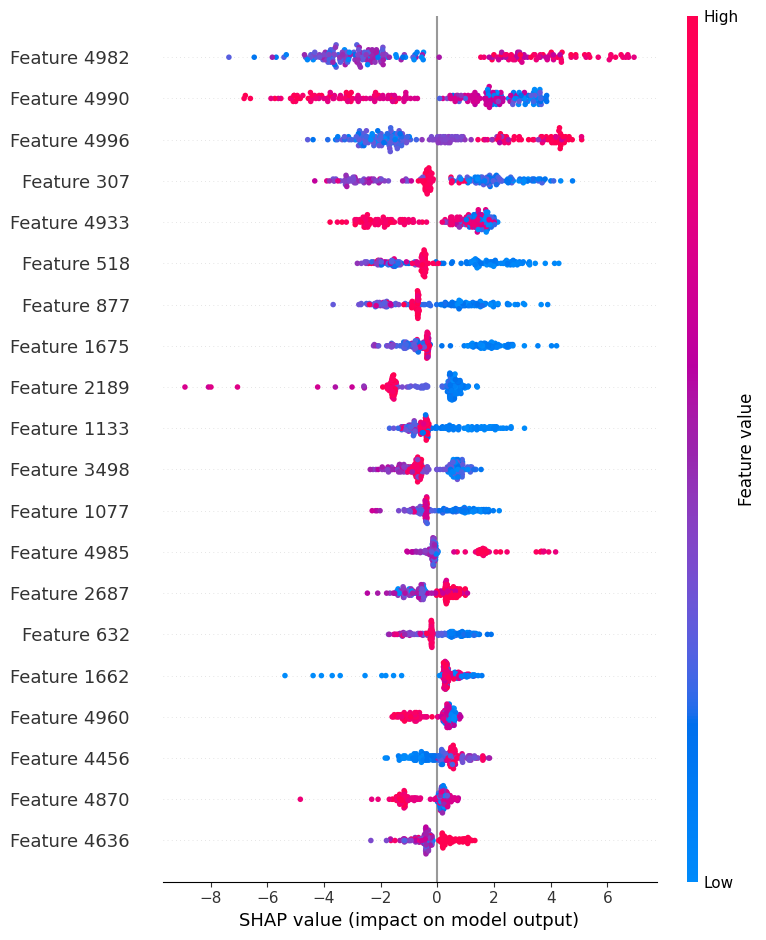

In [ ]:
import shap

# Sample for SHAP
idx = np.random.choice(X_train.shape[0], 200, replace=False)
X_shap = X_train[idx]

explainer = shap.Explainer(xgb_age_model)
shap_values = explainer(X_shap)

shap.summary_plot(shap_values, X_shap, show=True)


In [ ]:
def epigenetic_clock_app(patient_index=0):
    # -----------------------------
    # INPUT PANEL (Simulated)
    # -----------------------------
    X_patient = X_test[patient_index].reshape(1, -1)
    chronological_age = y_test_age[patient_index]

    # -----------------------------
    # AGE PREDICTION
    # -----------------------------
    bio_age_elastic = elastic_net_model.predict(X_patient)[0]
    bio_age_xgb = xgb_age_model.predict(X_patient)[0]

    # Ensemble biological age
    biological_age = (bio_age_elastic + bio_age_xgb) / 2

    # -----------------------------
    # AGE ACCELERATION
    # -----------------------------
    age_acceleration = biological_age - chronological_age

    # -----------------------------
    # DISEASE RISK LOGIC
    # -----------------------------
    if age_acceleration > 10:
        risk = "High Risk"
    elif age_acceleration > 5:
        risk = "Medium Risk"
    else:
        risk = "Low Risk"

    # -----------------------------
    # OUTPUT PANEL
    # -----------------------------
    print("🧬 EPIGENETIC CLOCK RESULT")
    print("--------------------------------")
    print(f"Chronological Age : {chronological_age}")
    print(f"Biological Age    : {biological_age:.2f}")
    print(f"Age Acceleration  : {age_acceleration:.2f}")
    print(f"Disease Risk      : {risk}")

    return X_patient, chronological_age, biological_age


In [ ]:
from sklearn.model_selection import train_test_split

X_train_age_local, X_test_age_local, y_train_age_local, y_test_age_local = train_test_split(
    X_age, ages, test_size=0.2, random_state=42
)

# Assign to the names that epigenetic_clock_app expects in the global scope
X_test = X_test_age_local
y_test_age = y_test_age_local
elastic_net_model = age_model # Alias the existing 'age_model' to 'elastic_net_model'

# Now call the function
X_patient, chrono_age, bio_age = epigenetic_clock_app(patient_index=5)


🧬 EPIGENETIC CLOCK RESULT
--------------------------------
Chronological Age : 80.0
Biological Age    : 83.27
Age Acceleration  : 3.27
Disease Risk      : Low Risk


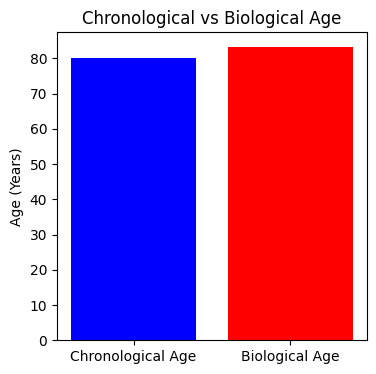

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4,4))
plt.bar(
    ["Chronological Age", "Biological Age"],
    [chrono_age, bio_age],
    color=["blue", "red"]
)
plt.title("Chronological vs Biological Age")
plt.ylabel("Age (Years)")
plt.show()


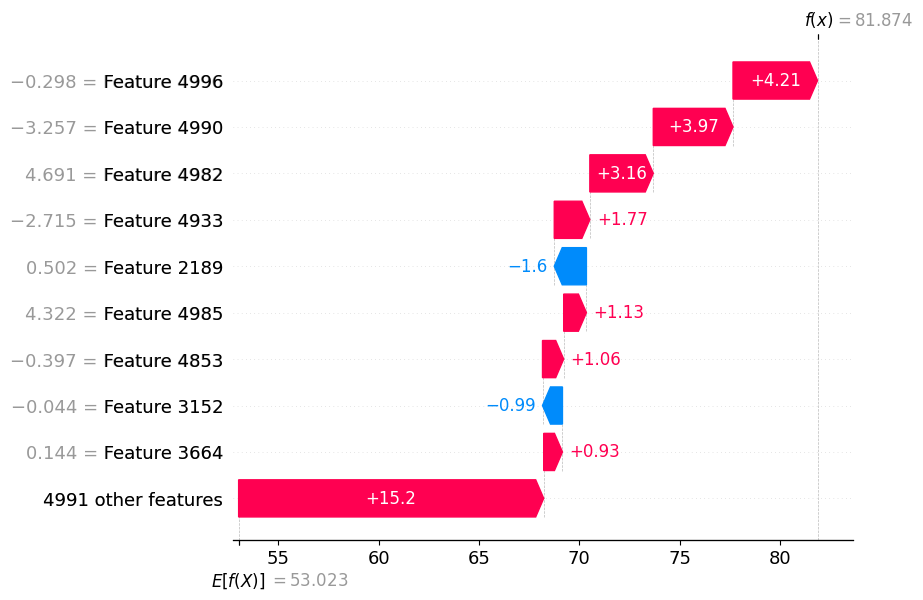

In [ ]:
import shap

explainer = shap.Explainer(xgb_age_model, X_train[:200])
shap_values = explainer(X_patient)

shap.plots.waterfall(shap_values[0])


In [ ]:
for i in range(3):
    print("\n==============================")
    epigenetic_clock_app(patient_index=i)



🧬 EPIGENETIC CLOCK RESULT
--------------------------------
Chronological Age : 80.0
Biological Age    : 74.01
Age Acceleration  : -5.99
Disease Risk      : Low Risk

🧬 EPIGENETIC CLOCK RESULT
--------------------------------
Chronological Age : 93.0
Biological Age    : 91.85
Age Acceleration  : -1.15
Disease Risk      : Low Risk

🧬 EPIGENETIC CLOCK RESULT
--------------------------------
Chronological Age : 68.0
Biological Age    : 34.06
Age Acceleration  : -33.94
Disease Risk      : Low Risk


In [ ]:
import joblib

joblib.dump(elastic_net_model, "elastic_net_age_model.pkl")
joblib.dump(xgb_age_model, "xgb_age_model.pkl")


['xgb_age_model.pkl']

In [ ]:
meta["disease"]


In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_disease = le.fit_transform(meta["disease"])


In [ ]:
disease_classes = le.classes_


In [ ]:
X_disease = X_age  # CpGs selected for epigenetic clock


In [ ]:
# Age acceleration for all samples
age_acc_all = (age_model.predict(X_age) - ages).reshape(-1, 1)

# CpG features already selected
X_disease = X_age

# Final disease feature matrix
X_disease_final = np.hstack([X_disease, age_acc_all])

print("Disease feature shape:", X_disease_final.shape)


Disease feature shape: (8233, 5001)


In [ ]:
from xgboost import XGBClassifier

disease_model = XGBClassifier(
    objective="multi:softprob",
    num_class=len(disease_classes),
    eval_metric="mlogloss",
    max_depth=6,
    learning_rate=0.1,
    n_estimators=200
)

disease_model.fit(X_disease_final, y_disease)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=10, ...)

In [ ]:
from sklearn.metrics import classification_report

y_pred_disease = disease_model.predict(X_disease_final)
print(classification_report(y_disease, y_pred_disease, target_names=disease_classes))

                      precision    recall  f1-score   support

 Alzheimer's disease       0.97      0.93      0.95       737
     Graves' disease       1.00      1.00      1.00        58
Huntington's disease       1.00      1.00      1.00       135
 Parkinson's disease       0.98      0.96      0.97       266
  Sjogren's syndrome       1.00      1.00      1.00        38
             control       0.99      1.00      0.99      6266
rheumatoid arthritis       1.00      1.00      1.00       159
       schizophrenia       1.00      1.00      1.00       381
              stroke       1.00      1.00      1.00       147
     type 2 diabetes       1.00      1.00      1.00        46

            accuracy                           0.99      8233
           macro avg       0.99      0.99      0.99      8233
        weighted avg       0.99      0.99      0.99      8233



In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_disease = le.fit_transform(meta["disease"])

# train disease_model using y_disease

In [ ]:
%%capture
!pip install gradio

In [ ]:
def predict_patient(sample_index, chronological_age):
    sample_index = int(sample_index)

    # CpG features for selected patient
    x_sample = X_age[sample_index].reshape(1, -1)

    # Predict biological age
    bio_age = age_model.predict(x_sample)[0]

    # Age acceleration
    age_acc = bio_age - chronological_age

    # Disease model input (CpGs + age acceleration)
    x_disease = np.hstack([x_sample, [[age_acc]]])

    # Predict disease
    disease_idx = disease_model.predict(x_disease)[0]
    predicted_disease = le.classes_[disease_idx]

    # Disease probability
    disease_prob = disease_model.predict_proba(x_disease)[0][disease_idx] * 100

    # Personalized recommendation (simple rule-based)
    if age_acc > 10:
        recommendation = "High biological aging detected. Lifestyle and clinical screening recommended."
    elif age_acc > 0:
        recommendation = "Mild age acceleration observed. Maintain healthy lifestyle."
    else:
        recommendation = "Biological age is lower than chronological age. Good health indicators."

    return (
        f"{bio_age:.2f}",
        f"{age_acc:.2f}",
        predicted_disease,
        f"{disease_prob:.2f} %",
        recommendation
    )

In [ ]:
import gradio as gr

with gr.Blocks(theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 🧬 AI-Driven Epigenetic Clock
    ### Biological Age & Disease Risk Prediction

    This system predicts **biological age from DNA methylation (CpG) data**,
    estimates **age acceleration**, and predicts **potential disease risk**.
    """)

    with gr.Row():
        with gr.Column():
            sample_index = gr.Number(
                label="Patient Index (from dataset)",
                value=20,
                precision=0
            )
            chrono_age = gr.Number(
                label="Chronological Age",
                value=40
            )
            submit = gr.Button("Predict", variant="primary")

        with gr.Column():
            bio_age_out = gr.Textbox(label="Predicted Biological Age")
            age_acc_out = gr.Textbox(label="Age Acceleration")
            disease_out = gr.Textbox(label="Predicted Disease")
            prob_out = gr.Textbox(label="Disease Probability")
            reco_out = gr.Textbox(label="Personalized Recommendation")

    submit.click(
        predict_patient,
        inputs=[sample_index, chrono_age],
        outputs=[
            bio_age_out,
            age_acc_out,
            disease_out,
            prob_out,
            reco_out
        ]
    )

demo.launch(share=True)

/tmp/ipython-input-1100852951.py:3: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://03a33100ae58324b7f.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
